In [1]:
library(tidyterra)
library(terra)
library(geodata)
library(rnaturalearth)
library(ggplot2)
library(dplyr)
library(sf)
library(rlang)
library(knitr)
library(leaflet)
library(htmlwidgets)
library(htmltools)
library(raster)
library(IRdisplay)


Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter




terra 1.9.27




Attaching package: ‘dplyr’




The following objects are masked from ‘package:terra’:

    intersect, union




...

The following object is masked from ‘package:terra’:

    spin




Loading required package: sp




Attaching package: ‘raster’




The following object is masked from ‘package:dplyr’:

    select




The following object is masked from ‘package:tidyterra’:

    select




## Top 14 (France)

The **Top 14** is France's premier professional rugby union league. This notebook samples **SRTM 30 arc-second** elevation from **`geodata::elevation_30s(country = "FRA")`** at each club's usual home ground and maps the results on a cropped national terrain surface.

**Stadium coordinates** below use approximate centre points for each club’s usual home ground. **La Rochelle** (Stade Marcel-Deflandre / Stade Rochelais) uses the published WGS84 location (46.158°N, 1.178°W). Replace the `top14_clubs` table and rebuild if you need a different season’s venues or survey-grade coordinates.

In [2]:
top14_clubs <- data.frame(
  club = c(
    "Toulouse", "Toulon", "La Rochelle", "Bordeaux", "Racing 92",
    "Stade Français", "Clermont", "Lyon", "Castres", "Montpellier",
    "Bayonne", "Pau", "Perpignan", "Montauban"
  ),
  stadium = c(
    "Stade Ernest-Wallon", "Stade Mayol", "Stade Marcel-Deflandre (Stade Rochelais)",
    "Matmut Atlantique", "Paris La Défense Arena", "Stade Jean-Bouin",
    "Stade Marcel-Michelin", "Matmut Stadium Gerland", "Stade Pierre-Fabre",
    "GGL Stadium", "Stade Jean-Dauger", "Stade du Hameau",
    "Stade Aimé-Giral", "Stade Sapiac"
  ),
  city = c(
    "Toulouse", "Toulon", "La Rochelle", "Bordeaux", "Nanterre",
    "Paris", "Clermont-Ferrand", "Lyon", "Castres", "Montpellier",
    "Bayonne", "Pau", "Perpignan", "Montauban"
  ),
  lon = c(
    1.415, 5.934, -1.17806, -0.598, 2.229,
    2.252, 3.106, 4.832, 2.249, 3.861,
    -1.486, -0.322, 2.894, 1.355
  ),
  lat = c(
    43.621, 43.125, 46.15806, 44.829, 48.895,
    48.844, 45.791, 45.724, 43.601, 43.590,
    43.484, 43.303, 42.711, 44.017
  ),
  region = c(
    "Occitanie", "Provence", "Atlantic coast", "Nouvelle-Aquitaine", "Paris",
    "Paris", "Massif Central", "Rhône-Alpes", "Occitanie", "Occitanie",
    "Basque Country", "Pyrenees", "Occitanie", "Occitanie"
  ),
  stringsAsFactors = FALSE
)

top14_sv <- terra::vect(top14_clubs, geom = c("lon", "lat"), crs = "EPSG:4326")

## Download elevation (France)

In [3]:
fra_elev <- geodata::elevation_30s(country = "FRA", path = tempdir())
fra_boundary <- rnaturalearth::ne_countries(
  country = "France",
  scale = "medium",
  returnclass = "sv"
)

if (!terra::same.crs(fra_elev, fra_boundary)) {
  fra_boundary <- terra::project(fra_boundary, fra_elev)
}

fra_elev_masked <- terra::mask(terra::crop(fra_elev, fra_boundary), fra_boundary)
elev_layer <- names(fra_elev_masked)[1]
fra_elev_masked <- fra_elev_masked |>
  tidyterra::rename(elevation = !!rlang::sym(elev_layer))

Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//RtmpToyPGp/elevation/FRA_elv_msk.zip



## Extract elevation per ground

Coastal grounds can fall on **SRTM water cells** (NA) when the 30 arc-second grid classifies harbour or tidal flats as offshore. For any NA at a stadium point we take the **nearest land cell** on the cropped (unmasked) national tile so the value still reflects local relief.

In [4]:
extract_ground_elev <- function(r, lon, lat, radius_deg = 0.05) {
  val <- terra::extract(r, cbind(lon, lat))[[1]]
  if (!is.na(val)) {
    return(as.numeric(val))
  }
  bb <- terra::ext(
    lon - radius_deg,
    lon + radius_deg,
    lat - radius_deg,
    lat + radius_deg
  )
  sub <- terra::crop(r, bb)
  cells <- which(!is.na(terra::values(sub)))
  if (!length(cells)) {
    return(NA_real_)
  }
  xy <- terra::xyFromCell(sub, cells)
  dist2 <- (xy[, 1] - lon)^2 + (xy[, 2] - lat)^2
  vals <- terra::values(sub)[cells]
  as.numeric(vals[which.min(dist2)])
}

fra_elev_crop <- terra::crop(fra_elev, fra_boundary)
names(fra_elev_crop) <- "elevation"

top14_elev <- top14_clubs |>
  mutate(
    ground_elevation_m = mapply(
      extract_ground_elev,
      lon,
      lat,
      MoreArgs = list(r = fra_elev_crop),
      USE.NAMES = FALSE
    )
  )

top14_elev |>
  arrange(desc(ground_elevation_m)) |>
  knitr::kable(
    digits = 1,
    caption = "Top 14 grounds ranked by extracted elevation (m a.s.l.; FRA SRTM tile)"
  )



Table: Top 14 grounds ranked by extracted elevation (m a.s.l.; FRA SRTM tile)

|club           |stadium                                  |city             |  lon|  lat|region             | ground_elevation_m|
|:--------------|:----------------------------------------|:----------------|----:|----:|:------------------|------------------:|
|Clermont       |Stade Marcel-Michelin                    |Clermont-Ferrand |  3.1| 45.8|Massif Central     |                351|
|Pau            |Stade du Hameau                          |Pau              | -0.3| 43.3|Pyrenees           |                230|
|Castres        |Stade Pierre-Fabre                       |Castres          |  2.2| 43.6|Occitanie          |                177|
|Lyon           |Matmut Stadium Gerland                   |Lyon             |  4.8| 45.7|Rhône-Alpes        |                165|
|Toulouse       |Stade Ernest-Wallon                      |Toulouse         |  1.4| 43.6|Occitanie          |                132|
|Montauba

**Clermont** and **Pau** sit on the **Massif Central** and **Pyrenean foothills**, where the 30 arc-second DEM routinely returns the highest values in this league. **Paris** clubs (**Racing 92**, **Stade Français**) and **La Rochelle** on the **Atlantic coast** tend to rank lower (at La Rochelle the stadium grid cell is classified as water in SRTM, so we report elevation from the nearest land cell a few hundred metres inland). **Toulon** and **Perpignan** are coastal but the grid cells can still reflect nearby relief.

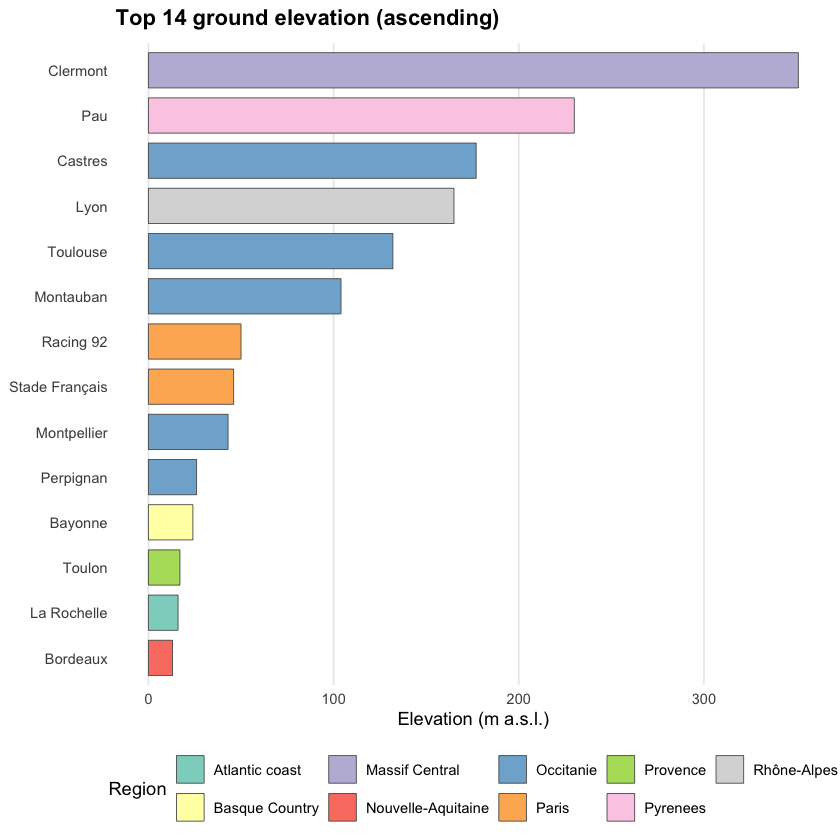

In [5]:
top14_bar <- top14_elev |>
  mutate(club = stats::reorder(club, ground_elevation_m))

ggplot(top14_bar, aes(x = club, y = ground_elevation_m, fill = region)) +
  geom_col(width = 0.78, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  scale_fill_brewer(palette = "Set3", name = "Region") +
  labs(
    title = "Top 14 ground elevation (ascending)",
    x = NULL,
    y = "Elevation (m a.s.l.)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0, margin = margin(b = 8)),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

## Map (France)

We **crop** the national raster to a modest bounding box around the Top 14 grounds so the map aspect remains readable.

In [6]:
map_ext <- terra::extend(terra::ext(top14_sv), 1.5)
r_top14 <- terra::crop(fra_elev_masked, map_ext)
outline_top14 <- terra::crop(fra_boundary, map_ext)

if (!terra::same.crs(r_top14, outline_top14)) {
  outline_top14 <- terra::project(outline_top14, r_top14)
}

<SpatRaster> resampled to 500656 cells.


Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the tidyterra package.
  Please report the issue at <https://github.com/dieghernan/tidyterra/issues>.”


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set2 is 8
Returning the palette you asked for with that many colors
”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_sf()`).”


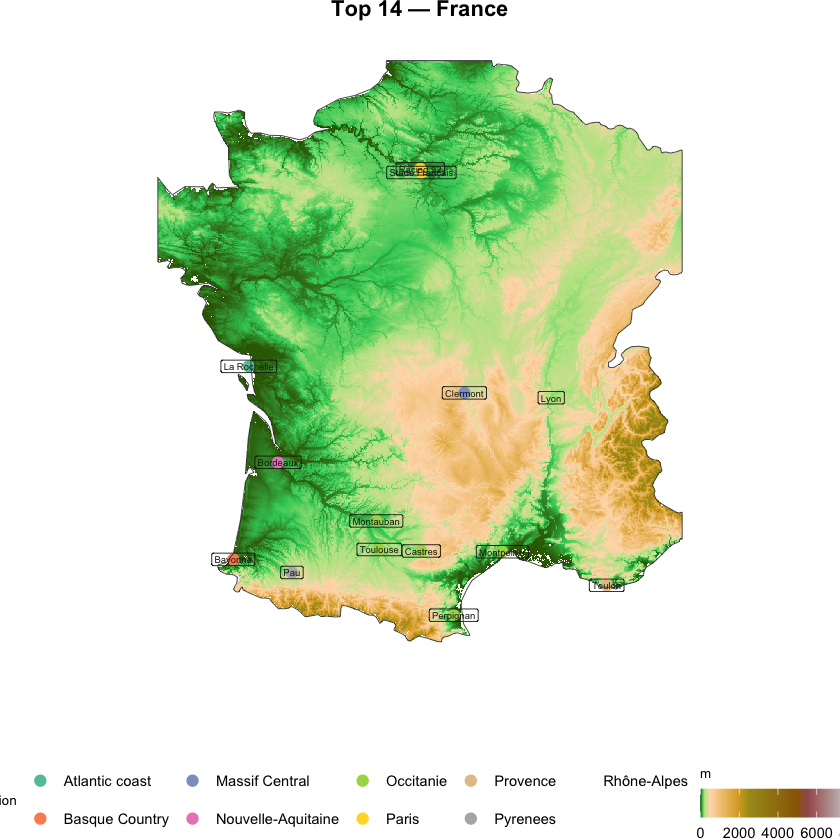

In [7]:
ggplot() +
  tidyterra::geom_spatraster(data = r_top14, aes(fill = elevation)) +
  tidyterra::scale_fill_hypso_tint_c(
    name = "m",
    guide = guide_colorbar(barwidth = unit(3.5, "cm"), title.position = "top")
  ) +
  tidyterra::geom_spatvector(data = top14_sv, aes(colour = region), size = 2.8, show.legend = TRUE) +
  tidyterra::geom_spatvector_label(
    data = top14_sv,
    aes(label = club),
    size = 2,
    colour = "grey10",
    label.size = 0.12,
    show.legend = FALSE
  ) +
  tidyterra::geom_spatvector(data = outline_top14, fill = NA, colour = "grey25", linewidth = 0.25) +
  scale_colour_brewer(palette = "Set2", name = "Region") +
  labs(title = "Top 14 — France") +
  theme_void() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, margin = margin(b = 4)),
    legend.title = element_text(size = 8),
    legend.position = "bottom"
  )

### Interactive map

The map below uses **Leaflet** (via **`htmlwidgets`**). You can **pan**, **zoom**, and click stadium markers for **club**, **venue**, and **extracted elevation**. Marker colours follow the same **elevation colour scale** as the terrain layer. An internet connection is required for the light **basemap** tiles.

In [8]:
flip_raster_east_west <- function(r) {
  mat <- terra::values(r, mat = TRUE)
  mat <- mat[, rev(seq_len(ncol(mat))), drop = FALSE]
  terra::values(r) <- mat
  r
}

leaflet_elev_map <- function(r, clubs_df) {
  r_small <- terra::aggregate(r, fact = 4, fun = mean)
  if (!grepl("4326", terra::crs(r_small, describe = TRUE)$code)) {
    r_small <- terra::project(r_small, "EPSG:4326")
  }
  r_small <- flip_raster_east_west(r_small)
  vals <- terra::values(r_small)
  vals <- vals[!is.na(vals)]
  elev_domain <- range(
    c(vals, clubs_df$ground_elevation_m),
    na.rm = TRUE
  )

  pal <- leaflet::colorNumeric(
    grDevices::terrain.colors(60),
    domain = elev_domain,
    na.color = "#808080"
  )

  lng1 <- terra::xmin(r_small)
  lng2 <- terra::xmax(r_small)
  lat1 <- terra::ymin(r_small)
  lat2 <- terra::ymax(r_small)
  bounds_ok <- all(is.finite(c(lng1, lng2, lat1, lat2))) &&
    lng1 < lng2 &&
    lat1 < lat2
  center_lng <- mean(clubs_df$lon, na.rm = TRUE)
  center_lat <- mean(clubs_df$lat, na.rm = TRUE)
  marker_fill <- unname(pal(clubs_df$ground_elevation_m))

  map <- leaflet::leaflet(
    width = "100%",
    height = 480,
    options = leaflet::leafletOptions(minZoom = 5)
  )

  map <- if (bounds_ok) {
    leaflet::fitBounds(map, lng1, lat1, lng2, lat2)
  } else {
    leaflet::setView(map, center_lng, center_lat, zoom = 6)
  }

  map |>
    leaflet::addProviderTiles(
      "CartoDB.Positron",
      group = "Basemap"
    ) |>
    leaflet::addRasterImage(
      r_small,
      colors = pal,
      opacity = 0.78,
      project = FALSE,
      group = "Elevation (SRTM)"
    ) |>
    leaflet::addLegend(
      pal = pal,
      values = vals,
      title = "Elevation (m)",
      position = "bottomright",
      opacity = 0.9
    ) |>
    leaflet::addCircleMarkers(
      lng = clubs_df$lon,
      lat = clubs_df$lat,
      radius = 8,
      stroke = TRUE,
      weight = 1.5,
      color = "#333333",
      fillColor = marker_fill,
      fillOpacity = 0.92,
      popup = paste0(
        "<strong>", clubs_df$club, "</strong><br>",
        clubs_df$stadium, "<br>",
        "<em>", clubs_df$city, "</em><br>",
        round(clubs_df$ground_elevation_m, 1), " m a.s.l."
      ),
      group = "Stadiums"
    ) |>
    leaflet::addLayersControl(
      baseGroups = "Basemap",
      overlayGroups = c("Elevation (SRTM)", "Stadiums"),
      options = leaflet::layersControlOptions(collapsed = FALSE)
    )
}

find_book_root <- function() {
  wd <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)
  for (steps in 0:6) {
    root <- if (steps == 0) {
      wd
    } else {
      normalizePath(
        file.path(wd, paste(rep("..", steps), collapse = "/")),
        winslash = "/",
        mustWork = FALSE
      )
    }
    if (file.exists(file.path(root, "_config.yml"))) {
      return(root)
    }
  }
  stop("Could not find Jupyter Book root (_config.yml).")
}

include_leaflet_map <- function(map, title, file_stem) {
  maps_dir <- file.path(find_book_root(), "_static", "uk-terrain-rugby", "maps")
  dir.create(maps_dir, recursive = TRUE, showWarnings = FALSE)
  out_path <- file.path(maps_dir, paste0(file_stem, ".html"))
  suppressWarnings(htmlwidgets::saveWidget(map, out_path, selfcontained = TRUE))
  iframe_src <- paste0("../../_static/uk-terrain-rugby/maps/", file_stem, ".html")
  iframe_html <- sprintf(
    paste0(
      "<h4 style=\"text-align:center;font-weight:bold;margin:0.6em 0 0.2em 0;\">%s</h4>",
      "<iframe src=\"%s\" title=\"%s\" width=\"100%%\" height=\"500\" ",
      "style=\"border:none;\"></iframe>"
    ),
    htmltools::htmlEscape(title),
    iframe_src,
    htmltools::htmlEscape(title)
  )
  IRdisplay::display_html(iframe_html)
  invisible(NULL)
}

In [9]:
include_leaflet_map(
  leaflet_elev_map(r_top14, top14_elev),
  "Top 14 — France (interactive)",
  "top14_france"
)

Top 14 — France (interactive)

The static and interactive maps highlight how France's **rugby heartland** in the **south-west** mixes **coastal** venues with **Massif Central** and **Pyrenean** outliers—useful context when comparing ground elevation across the league.